## EDA (Exploratory Data Analysis)

### Business Overview

In [1]:
## Import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
## Load Dataset
df = pd.read_csv("../data/processed/Cleaned-Telco-Customer-Churn.csv")

df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


### 1. What is the overall churn rate of customers in the dataset?

In [3]:
churn_rate = round((df['Churn'].value_counts()/len(df['Churn']))*100, 2)
churn_rate

Churn
No     73.42
Yes    26.58
Name: count, dtype: float64

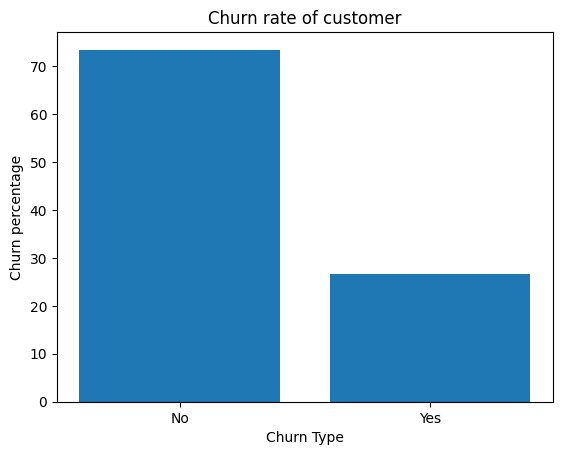

In [4]:
plt.bar(x=churn_rate.keys(), height=churn_rate.values)
plt.xlabel("Churn Type")
plt.ylabel("Churn percentage")
plt.title("Churn rate of customer");

#### Comments:
We can see that customer churn rate is approximately 26.58% in the dataset, indicating that about one in four customers have discontinued their service. This high churn rate suggests that the company may need to investigate the underlying reasons for customer attrition and implement strategies to improve customer retention.

### 2. How does churn vary by customer tenure (new vs long-term customers)?

We can categorize customers based on their tenure into three groups:
* New Customers (0-6 months) - High risky as they are still evaluating the service.
* Mid-term Customers (6-24 months) - Moderate risk as they have some experience with the service.
* Long-term Customers (24+ months) - Low risk as they are more likely to be satisfied with the service.

In [5]:
df['tenure'].unique()

array([ 1, 34,  2, 45,  8, 22, 10, 62, 13, 16, 58, 49, 69, 52, 71, 21, 12,
       30, 47, 17, 72,  5, 46, 11, 70, 63, 43, 25, 60, 18,  9,  3, 31, 50,
       64, 56,  7, 42, 35, 48, 29, 66, 65, 38, 68, 32, 55, 37, 36, 41, 27,
        6,  4, 33, 67, 23, 57, 61, 15, 14, 20, 53, 40, 59, 24, 44, 19, 54,
       51, 28, 26, 39])

In [6]:
## Customer segmentation
df['tenure'] = df['tenure'].apply(lambda x: '0-6' if x<=6 else('6-24' if 6<x<=24 else '24+'))

df['tenure']

0        0-6
1        24+
2        0-6
3        24+
4        0-6
        ... 
7016     24+
7017    6-24
7018    6-24
7019     0-6
7020     24+
Name: tenure, Length: 7021, dtype: object

In [7]:
## How churn vary by customer tenure
tenure_wise_churn_rate = df.groupby(['tenure'])['Churn'].value_counts(normalize=True).round(2).to_frame(name='churn_rate')

tenure_wise_churn_rate

churn_rate
tenure Churn            
0-6    Yes          0.53
       No           0.47
24+    No           0.86
       Yes          0.14
6-24   No           0.68
       Yes          0.32

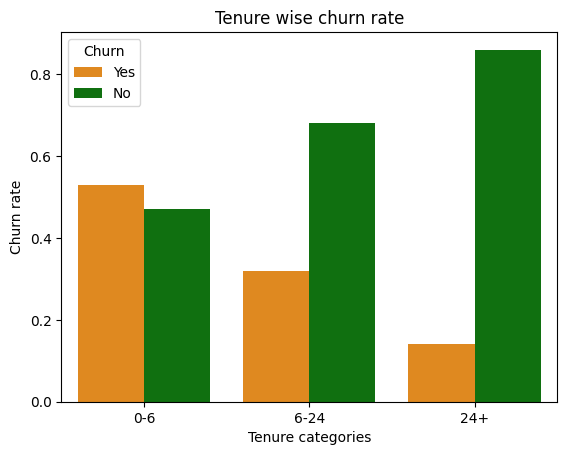

In [19]:
sns.barplot(data=tenure_wise_churn_rate, x='tenure', y='churn_rate',hue='Churn',  order=['0-6', '6-24', '24+'], palette=['darkorange', 'green'])
plt.title("Tenure wise churn rate")
plt.xlabel("Tenure categories")
plt.ylabel("Churn rate");

#### Comments:
The above analysis shows that:
* New customers (0-6 months) have the highest churn rate at approximately 53%, indicating that they are more likely to discontinue the service shortly after joining. 
* Mid-term customers (6-24 months) have a moderate churn rate of around 32%, 
* While long-term customers (24+ months) exhibit the lowest churn rate at about 14%. 

This trend suggests that customer retention improves with longer tenure, highlighting the importance of engaging and satisfying new customers to reduce early churn.

### 3. What percentage of total revenue is at risk due to churn?

In [9]:
## Percentage of tatal revenue based on churn
(df.groupby(['Churn'])['TotalCharges'].sum()/df['TotalCharges'].sum()).round(2)*100

Churn
No     82.0
Yes    18.0
Name: TotalCharges, dtype: float64

##### Comments:
The analysis indicates that approximately 18% of total revenue is at risk due to customer churn. This significant percentage highlights the financial impact of churn on the company's revenue stream.

### 4. How does churn trend differ across monthly vs yearly contracts?

In [10]:
## Churn trend on different contract type
contract_wist_churn_rate = df.groupby(['Contract'])['Churn'].value_counts(normalize=True).round(2).to_frame()

contract_wist_churn_rate

proportion
Contract       Churn            
Month-to-month No           0.57
               Yes          0.43
One year       No           0.89
               Yes          0.11
Two year       No           0.97
               Yes          0.03

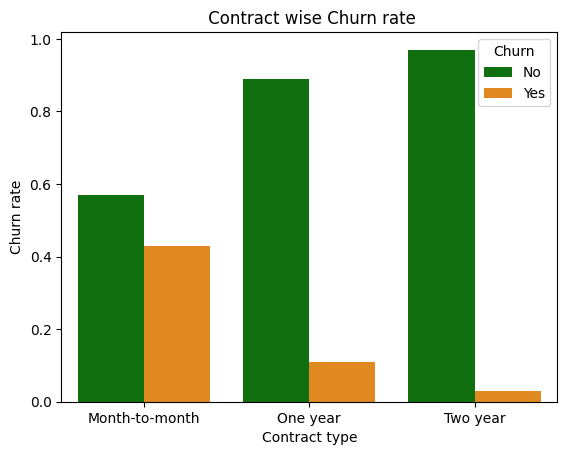

In [21]:
sns.barplot(data=contract_wist_churn_rate, x='Contract', y='proportion', hue='Churn', palette=['green', 'darkorange'])
plt.title(" Contract wise Churn rate")
plt.xlabel('Contract type')
plt.ylabel('Churn rate');

#### Comments:
The analysis indicates that:
* Month-to-month contract customers have a significantly higher churn rate (approximately 43%) compared to those on one-year (around 11%) and two-year contracts (about 3%). 

This suggests that customers with longer-term commitments are less likely to churn.

### 5. Which customer segments contribute most to churn volume?

In [12]:
## Customer segment 
customer_segment_with_churn = pd.pivot_table(data=df, index=['Churn', 'tenure'], columns=['Contract'], aggfunc='size').loc['Yes', :].fillna(0)

customer_segment_with_churn

Contract,Month-to-month,One year,Two year
tenure,,,
0-6,779.0,4.0,0.0
24+,352.0,137.0,48.0
6-24,521.0,25.0,0.0


In [13]:
customer_segment_with_churn_pct = ((customer_segment_with_churn/customer_segment_with_churn.sum().sum())*100).round(2)

customer_segment_with_churn_pct

Contract,Month-to-month,One year,Two year
tenure,,,
0-6,41.75,0.21,0.00
24+,18.86,7.34,2.57
6-24,27.92,1.34,0.00


In [14]:
filtered_customer_segment_with_churn_pct = customer_segment_with_churn_pct.stack()[customer_segment_with_churn_pct.stack()>0]

filtered_customer_segment_with_churn_pct

tenure  Contract      
0-6     Month-to-month    41.75
        One year           0.21
24+     Month-to-month    18.86
        One year           7.34
        Two year           2.57
6-24    Month-to-month    27.92
        One year           1.34
dtype: float64

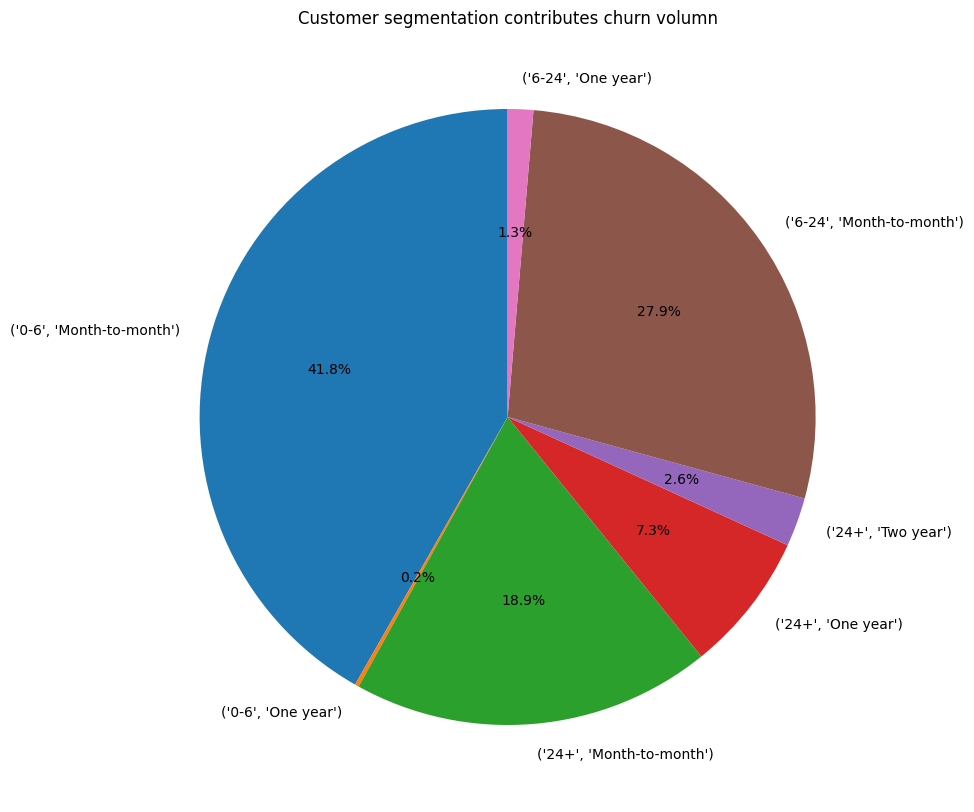

In [15]:
## Pie Chart
plt.figure(figsize=(10,10))
x = filtered_customer_segment_with_churn_pct.values
label = filtered_customer_segment_with_churn_pct.index

plt.pie(x=x, labels=label, autopct='%1.1f%%', startangle=90)
plt.title('Customer segmentation contributes churn volumn');

---
### Author Information
**Name:** [Apabrita Maity]  
**Date:** 2026-01-07  
**Role:** [Data Analyst | Data Scientist]

### Let's Connect!
If you have questions about this analysis or would like to collaborate, feel free to reach out:

*  **LinkedIn:** [LinkedIn](https://www.linkedin.com/in/apabritamaity/)
*  **GitHub:** [@apabritamaity](https://github.com/apabritamaity/data-analyst-portfolio)
*  **Email:** [contacttoapabrita@gmail.com](mailto:contacttoapabrita@gmail.com)